<a href="https://colab.research.google.com/github/derewor/SNP_for_GWAS/blob/main/GWAS_ILA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

### 1. Removal of minor allels and LD pruning to reduce non informative allels.

### Conduct the MAF and LD pruning separately for each chromosme.

In [ ]:
chr1_hf = pd.read_csv('chr1_hf.csv')

In [ ]:
# remove the freq field.
chr1_hf = chr1_hf.drop(columns='freq')
chr1_hf.head(3)

,Position,430,991,1062,1063,1254,1925,2276,5831,5856,...,9904,9906,9927,9938,9942,9948,9949,9950,10005,10017
0,92,0,0,1,0,0,1,0,0,0,...,1,0,1,1,0,0,0,1,0,0
1,110,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,253,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [ ]:
# LD pruning requires that the SNP are in columns and the sample in rows. So, transpose the df.
chr1_hft = chr1_hf.T
chr1_hft.head()

,0,1,2,3,4,5,6,7,8,9,...,458274,458275,458276,458277,458278,458279,458280,458281,458282,458283
Position,92,110,253,346,353,363,419,425,471,502,...,30427302,30427312,30427336,30427349,30427357,30427366,30427403,30427488,30427503,30427516
430,0,0,0,0,0,0,0,0,0,0,...,1,1,0,0,1,1,0,1,0,1
991,0,0,0,1,0,0,0,0,0,1,...,1,1,0,0,1,1,0,1,0,1
1062,1,0,0,0,1,0,0,1,1,0,...,1,1,0,0,1,1,0,1,0,1
1063,0,0,0,0,0,0,0,0,0,0,...,1,1,0,0,1,1,0,1,0,1


In [ ]:
# set the position as names of columns.
chr1_hft.columns = chr1_hft.iloc[0]
chr1_hft = chr1_hft[1:]
chr1_hft.head()

Position,92,110,253,346,353,363,419,425,471,502,...,30427302,30427312,30427336,30427349,30427357,30427366,30427403,30427488,30427503,30427516
430,0,0,0,0,0,0,0,0,0,0,...,1,1,0,0,1,1,0,1,0,1
991,0,0,0,1,0,0,0,0,0,1,...,1,1,0,0,1,1,0,1,0,1
1062,1,0,0,0,1,0,0,1,1,0,...,1,1,0,0,1,1,0,1,0,1
1063,0,0,0,0,0,0,0,0,0,0,...,1,1,0,0,1,1,0,1,0,1
1254,0,0,0,1,0,0,0,0,0,1,...,1,1,0,0,1,1,0,1,0,1


In [ ]:
# LD threshold
threshold = 0.8
# SNP matrix
X = chr1_hft.values
# # SNP positions
positions = chr1_hft.columns.tolist()
# SNPs to remove
remove = set() # it creates uniques values that show membership.

In [ ]:
# define a function that selects high frequency snps.
def high_frequency(df, name="output"):
    # 1. allele frequency (assuming 1 = present, 0 = absent)
    df = df.drop(columns='Chromosome').set_index('Position')
    df = df.copy()
    # convert all values to numeric
    df = df.apply(pd.to_numeric, errors='coerce')
    # count number of present alleles per SNP
    df['freq'] = df.sum(axis=1)
    # 2. filter SNPs with frequency > 11
    df_hf = df[df['freq'] > 11].drop(columns=['freq'])
    # save file
    df_hf.to_csv(f"{name}_hf.csv")
    return df_hf

In [ ]:
df5 = pd.read_csv('/Users/dworkum/data_icloud/PycharmProjects/Bioinformatics_training/chr5_snp,tsv', delimiter='\t')
chr5_snps = df5.copy()

In [ ]:
# select high frequent alles from chr_2
chr5_hf = high_frequency(chr5_snps)
chr5_hf.shape

NameError: name 'high_frequency' is not defined

In [ ]:
# save the chr2_hf to csv.
chr5_hf.to_csv('chr5_hfs.csv')

In [ ]:
def ld_prune(df_hf, threshold=0.8, window=200, out_file="pruned_snps.csv"):
    df_hft = df_hf.T
    # optional: ensure numeric
    df_hft = df_hft.apply(pd.to_numeric, errors='coerce')
    # 4. matrix + positions
    X = df_hft.values
    positions = df_hft.columns.tolist()
    remove = set()
    # 5. LD pruning
    for i in range(len(positions)):
        if positions[i] in remove:
            continue
        snp1 = X[:, i]
        for j in range(i + 1, min(i + window, len(positions))):
            if positions[j] in remove:
                continue
            snp2 = X[:, j]
            # skip non-variable SNPs
            if np.nanstd(snp1) == 0 or np.nanstd(snp2) == 0:
                continue
            r = np.corrcoef(snp1, snp2)[0, 1]
            if np.isnan(r):
                continue
            if r**2 > threshold:
                remove.add(positions[j])
    # 6. keep SNPs
    kept = [p for p in positions if p not in remove]
    pruned_df = df_hft[kept]
    # 7. save
    pruned_df.to_csv(out_file)
    return pruned_df

In [ ]:
# generate the pruned snp df for each chromosome
chr5_hf1 = ld_prune(chr5_hf)

In [ ]:
chr5_hf1.shape

In [ ]:
# save the snps as df.
chr5_hf1.to_csv('chr5_snps.csv')

### 2. Merging SNPs from individual chromosme.

In [ ]:
chr1 = pd.read_csv('/Users/dworkum/Library/Mobile Documents/com~apple~CloudDocs/Documents/PycharmProjects/Bioinformatics_training/high_frequency_allels/chr1_snp.csv')

FileNotFoundError: [Errno 2] No such file or directory: '/Users/dworkum/Library/Mobile Documents/com~apple~CloudDocs/Documents/PycharmProjects/Bioinformatics_training/high_frequency_allels/chr1_snp.csv'

In [ ]:
chr2 = pd.read_csv('/Users/dworkum/Library/Mobile Documents/com~apple~CloudDocs/Documents/PycharmProjects/Bioinformatics_training/high_frequency_allels/chr2_snps.csv')

In [ ]:
chr3 = pd.read_csv('/Users/dworkum/Library/Mobile Documents/com~apple~CloudDocs/Documents/PycharmProjects/Bioinformatics_training/high_frequency_allels/chr3_snps.csv')

In [ ]:
chr4 = pd.read_csv('/Users/dworkum/Library/Mobile Documents/com~apple~CloudDocs/Documents/PycharmProjects/Bioinformatics_training/high_frequency_allels/chr4_snps.csv')

In [ ]:
chr5 = pd.read_csv('/Users/dworkum/Library/Mobile Documents/com~apple~CloudDocs/Documents/PycharmProjects/Bioinformatics_training/high_frequency_allels/chr5_snps.csv')

In [ ]:
print(chr1.shape, chr2.shape, chr3.shape, chr4.shape, chr5.shape)

(222, 128501) (222, 80205) (222, 107118) (222, 86288) (222, 110047)


In [ ]:
chr1_t = chr1.T
chr1_t.columns = chr1_t.iloc[0]
chr1_t = chr1_t[1:]
chr1_t['chromosome'] = 'chr1'
chr1_t.head()

Unnamed: 0,430,991,1062,1063,1254,1925,2276,5831,5856,5867,...,9906,9927,9938,9942,9948,9949,9950,10005,10017,chromosome
92,0,0,1,0,0,1,0,0,0,0,...,0,1,1,0,0,0,1,0,0,chr1
110,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,chr1
253,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,chr1
346,0,1,0,0,1,0,1,0,1,1,...,0,0,0,1,0,0,0,0,0,chr1
353,0,0,1,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,chr1


In [ ]:
# process and merge the files.
def merge_files(dfs):
    processed = []
    for i, df in enumerate(dfs, start=1):
        df_t = df.T
        # If first row contains headers (only if that is true in your data)
        df_t.columns = df_t.iloc[0]
        df_t = df_t[1:]
        # Add chromosome label correctly
        df_t["chromosome"] = f"chr{i}"
        processed.append(df_t)
    snp_final = pd.concat(processed, axis=0)
    return snp_final

In [ ]:
# merged files
dfs = [chr1, chr2, chr3, chr4, chr5]
snp_final = merge_files(dfs)
snp_final = snp_final.reset_index()
snp_final = snp_final.rename(columns={'index':'position'})
snp_final.head()

Unnamed: 0,position,430,991,1062,1063,1254,1925,2276,5831,5856,...,9906,9927,9938,9942,9948,9949,9950,10005,10017,chromosome
0,92,0,0,1,0,0,1,0,0,0,...,0,1,1,0,0,0,1,0,0,chr1
1,110,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,chr1
2,253,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,chr1
3,346,0,1,0,0,1,0,1,0,1,...,0,0,0,1,0,0,0,0,0,chr1
4,353,0,0,1,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,chr1


In [ ]:
# extract the metadata of snp position and chromosome number.
column_meta = ['position','chromosome']
meta_data = snp_final[column_meta]
meta_data.head()

Unnamed: 0,position,chromosome
0,92,chr1
1,110,chr1
2,253,chr1
3,346,chr1
4,353,chr1


In [ ]:
# save the metadata as csv
meta_data.to_csv('metadata.csv')

In [ ]:
# sace the merged file as csv.
snp_final.to_csv('snp_arab.csv')

In [ ]:
snp_data = snp_final.T.copy()

In [ ]:
snp_data = snp_data.reset_index()
snp_data = snp_data.rename(columns={'Unnamed: 0':'Accession'})
snp_data.head()

,Accession,0,1,2,3,4,5,6,7,8,...,512144,512145,512146,512147,512148,512149,512150,512151,512152,512153
0,position,92,110,253,346,353,363,419,502,508,...,26970761,26970843,26971522,26973058,26974485,26974816,26974820,26974938,26975272,26975377
1,430,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,1,0,0,0,0
2,991,0,0,0,1,0,0,0,1,1,...,0,1,0,0,0,1,0,0,1,0
3,1062,1,0,0,0,1,0,0,0,1,...,0,0,0,0,0,1,0,0,0,1
4,1063,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1


In [ ]:
accessions_list = snp_data.Accession.astype(str).to_list()
len(accessions_list)

224

## 3. Import the phenotype data

## A. MS roots

In [ ]:
root_ms = pd.read_csv('/Users/dworkum/data_icloud/PycharmProjects/Bioinformatics_training/ms_d10.csv', delimiter =';', on_bad_lines='skip')
root_ms['Accession'] = root_ms['Accession'].astype(str).str.replace('Col-0', '6909')
# root_ms = root_ms.drop(columns = ['Unnamed: 11','Unnamed: 12','Unnamed: 13']).astype(float)
display(root_ms.head())
root_ms.shape

,Accession,R1,R2,R3,R4,R5,R6,R7,R8,R9,R10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,430,"0,96","0,23","2,75","1,90","1,97","1,08",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,991,"5,09","5,74","3,84","4,66","2,69","4,81","5,88",NaN,NaN,NaN,NaN,NaN,NaN
2,997,"2,03","2,10",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1062,"3,02","2,69","2,97","1,27","3,96","1,55","2,25",NaN,NaN,NaN,NaN,NaN,NaN
4,1063,"3,29","2,71","2,90","2,43","2,86",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


(267, 14)

In [ ]:
# select accessions whose numner is in the accessions list.
root_ms_selected = root_ms[root_ms['Accession'].isin(accessions_list)].copy()
root_ms_selected['Accession'] = root_ms_selected['Accession'].astype(int)
root_ms_selected = root_ms_selected.sort_values(by='Accession', ascending=True)
root_ms_selected = root_ms_selected[~root_ms_selected['Accession'].duplicated(keep='first')]
ms_roots = root_ms_selected.copy()
ms_roots

,Accession,R1,R2,R3,R4,R5,R6,R7,R8,R9,R10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,430,"0,96","0,23","2,75","1,90","1,97","1,08",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,991,"5,09","5,74","3,84","4,66","2,69","4,81","5,88",NaN,NaN,NaN,NaN,NaN,NaN
3,1062,"3,02","2,69","2,97","1,27","3,96","1,55","2,25",NaN,NaN,NaN,NaN,NaN,NaN
4,1063,"3,29","2,71","2,90","2,43","2,86",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1254,"2,58","2,33","1,74","0,80","1,84","1,34",NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,9948,"5,10","3,40","1,30","4,20","2,85","3,73","4,41","4,09",NaN,NaN,NaN,NaN,NaN
262,9949,"1,66","1,80","2,33","3,90","1,40","3,40","3,98","3,89",NaN,NaN,NaN,NaN,NaN
263,9950,"4,85","4,97","4,81","4,32","3,68","3,98","3,94",NaN,NaN,NaN,NaN,NaN,NaN
264,10005,"3,38","4,44","4,57","2,26","4,76","2,73","3,92",NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# set accessions as index
ms_roots = ms_roots.set_index('Accession').drop(columns=['Unnamed: 11','Unnamed: 12','Unnamed: 13'])
ms_roots['num_roots'] = ms_roots.count(axis=1)
ms_roots['total_seeds'] = 12

In [ ]:
ms_roots1 = ms_roots.replace(',', '.', regex=True).astype(float)
ms_roots1

,R1,R2,R3,R4,R5,R6,R7,R8,R9,R10,num_roots,total_seeds
Accession,,,,,,,,,,,,
430,0.96,0.23,2.75,1.90,1.97,1.08,NaN,NaN,NaN,NaN,6.0,12.0
991,5.09,5.74,3.84,4.66,2.69,4.81,5.88,NaN,NaN,NaN,7.0,12.0
1062,3.02,2.69,2.97,1.27,3.96,1.55,2.25,NaN,NaN,NaN,7.0,12.0
1063,3.29,2.71,2.90,2.43,2.86,NaN,NaN,NaN,NaN,NaN,5.0,12.0
1254,2.58,2.33,1.74,0.80,1.84,1.34,NaN,NaN,NaN,NaN,6.0,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...
9948,5.10,3.40,1.30,4.20,2.85,3.73,4.41,4.09,NaN,NaN,8.0,12.0
9949,1.66,1.80,2.33,3.90,1.40,3.40,3.98,3.89,NaN,NaN,8.0,12.0
9950,4.85,4.97,4.81,4.32,3.68,3.98,3.94,NaN,NaN,NaN,7.0,12.0


In [ ]:
ms_roots2 =ms_roots1.query('num_roots >= 5')
ms_roots2.shape

(221, 12)

In [ ]:
# Calculate the average root_lenght and germination percentage
ms_roots2['ms_gerpct'] = (ms_roots2['num_roots'] / ms_roots2['total_seeds']).round(2)

/var/folders/rk/kh1g1yz15_b539v1q19bprcr0000gn/T/ipykernel_1311/1209652131.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ms_roots2['ms_gerpct'] = (ms_roots2['num_roots'] / ms_roots2['total_seeds']).round(2)


In [ ]:
ms_roots2.head(2)
ms_roots2c = ms_roots2.reset_index()

In [ ]:
ms_root3 = ms_roots2.iloc[: ,0:10]
ms_root3['ms_rlen'] = ms_root3.astype(float).mean(axis=1).round(2)
ms_root3 = ms_root3.reset_index()
ms_root3

,Accession,R1,R2,R3,R4,R5,R6,R7,R8,R9,R10,ms_rlen
0,430,0.96,0.23,2.75,1.90,1.97,1.08,NaN,NaN,NaN,NaN,1.48
1,991,5.09,5.74,3.84,4.66,2.69,4.81,5.88,NaN,NaN,NaN,4.67
2,1062,3.02,2.69,2.97,1.27,3.96,1.55,2.25,NaN,NaN,NaN,2.53
3,1063,3.29,2.71,2.90,2.43,2.86,NaN,NaN,NaN,NaN,NaN,2.84
4,1254,2.58,2.33,1.74,0.80,1.84,1.34,NaN,NaN,NaN,NaN,1.77
...,...,...,...,...,...,...,...,...,...,...,...,...
216,9948,5.10,3.40,1.30,4.20,2.85,3.73,4.41,4.09,NaN,NaN,3.64
217,9949,1.66,1.80,2.33,3.90,1.40,3.40,3.98,3.89,NaN,NaN,2.80
218,9950,4.85,4.97,4.81,4.32,3.68,3.98,3.94,NaN,NaN,NaN,4.36
219,10005,3.38,4.44,4.57,2.26,4.76,2.73,3.92,NaN,NaN,NaN,3.72


In [ ]:
root_len = ms_root3[['Accession','ms_rlen']]

In [ ]:
ms_rt = pd.merge(ms_root3[['Accession','ms_rlen']], ms_roots2c[['Accession', 'ms_gerpct']], how='inner', on='Accession')
ms_rt

,Accession,ms_rlen,ms_gerpct
0,430,1.48,0.50
1,991,4.67,0.58
2,1062,2.53,0.58
3,1063,2.84,0.42
4,1254,1.77,0.50
...,...,...,...
216,9948,3.64,0.67
217,9949,2.80,0.67
218,9950,4.36,0.58
219,10005,3.72,0.58


In [ ]:
ms_rt['Accession'] = ms_rt['Accession'].astype(str)
ms_rt.to_csv('ms_rt.csv')

In [ ]:
ms_accessions = ms_rt['Accession'].to_list()

## B. ILA roots

In [ ]:
root_ila = pd.read_csv('/Users/dworkum/data_icloud/PycharmProjects/Bioinformatics_training/ila_d10.csv', delimiter =';', on_bad_lines='skip')
root_ila['Accession'] = root_ila['Accession'].astype(str).str.replace('Col-0', '6909')
root_ila = root_ila.drop(columns = ['Accession.1','Mean'])
root_ila = root_ila.replace(',', '.', regex=True)
root_ila.columns = ['Accession','R1','R2','R3','R4','R5','R6','R7','R8','R9','R10']
display(root_ila.head())
root_ila.shape

,Accession,R1,R2,R3,R4,R5,R6,R7,R8,R9,R10
0,430,1.52,0.67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,991,3.48,1.78,3.12,3.34,2.57,2.99,2.10,2.24,NaN,NaN
2,997,0.45,1.96,1.23,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1062,3.34,1.43,0.21,3.02,1.34,1.48,1.85,NaN,NaN,NaN
4,1063,NaN,0.44,0.44,0.84,0.51,0.59,NaN,NaN,NaN,NaN


(287, 11)

In [ ]:
# filter the accession which are in ms_roots.
root_ila_filtered = root_ila[root_ila['Accession'].isin(ms_accessions)]
root_ila_filtered.head()

,Accession,R1,R2,R3,R4,R5,R6,R7,R8,R9,R10
0,430,1.52,0.67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,991,3.48,1.78,3.12,3.34,2.57,2.99,2.10,2.24,NaN,NaN
3,1062,3.34,1.43,0.21,3.02,1.34,1.48,1.85,NaN,NaN,NaN
4,1063,NaN,0.44,0.44,0.84,0.51,0.59,NaN,NaN,NaN,NaN
5,1254,1.45,1.76,0.72,0.94,1.48,0.78,1.15,1.88,NaN,NaN


In [ ]:
# set accession as index and change the values of all features to float.
root_ila_filtered = root_ila_filtered.set_index('Accession')

In [ ]:
# change the datatype
root_ila_filtered = root_ila_filtered.astype(float)
#root_ila_filtered.info()

In [ ]:
# filter rows which contain at least 5 grown roots.
root_ila_filtered['num_roots'] = root_ila_filtered.count(axis=1)
root_ila_filtered.head()

,R1,R2,R3,R4,R5,R6,R7,R8,R9,R10,num_roots
Accession,,,,,,,,,,,
430,1.52,0.67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
991,3.48,1.78,3.12,3.34,2.57,2.99,2.10,2.24,NaN,NaN,8
1062,3.34,1.43,0.21,3.02,1.34,1.48,1.85,NaN,NaN,NaN,7
1063,NaN,0.44,0.44,0.84,0.51,0.59,NaN,NaN,NaN,NaN,5
1254,1.45,1.76,0.72,0.94,1.48,0.78,1.15,1.88,NaN,NaN,8


In [ ]:
root_ila_final = root_ila_filtered.query('num_roots > 5')
ila_roots = root_ila_final.copy()

In [ ]:
# add the total nummer of seeds sown
ila_roots['total_seeds'] = 12
ila_roots

,R1,R2,R3,R4,R5,R6,R7,R8,R9,R10,num_roots,total_seeds
Accession,,,,,,,,,,,,
991,3.48,1.78,3.12,3.34,2.57,2.99,2.10,2.24,NaN,NaN,8,12
1062,3.34,1.43,0.21,3.02,1.34,1.48,1.85,NaN,NaN,NaN,7,12
1254,1.45,1.76,0.72,0.94,1.48,0.78,1.15,1.88,NaN,NaN,8,12
1925,0.64,2.00,1.85,0.59,0.67,0.63,0.81,NaN,NaN,NaN,7,12
2276,NaN,1.55,1.23,1.50,1.20,0.89,0.70,1.05,NaN,NaN,7,12
...,...,...,...,...,...,...,...,...,...,...,...,...
6909,NaN,2.32,3.85,3.41,2.77,2.03,2.93,2.55,NaN,NaN,7,12
6909,2.66,3.52,3.59,1.36,2.40,3.02,2.49,NaN,NaN,NaN,7,12
6909,2.81,2.38,2.39,2.88,2.64,2.33,2.08,3.01,NaN,NaN,8,12


In [ ]:
ila_roots['ila_rlen'] = ila_roots.mean(axis=1).round(2)
ila_roots['ila_pctger'] = ((ila_roots['num_roots'] - 1) / ila_roots['total_seeds']).round(2)
ila_roots

,R1,R2,R3,R4,R5,R6,R7,R8,R9,R10,num_roots,total_seeds,ila_rlen,ila_pctger
Accession,,,,,,,,,,,,,,
991,3.48,1.78,3.12,3.34,2.57,2.99,2.10,2.24,NaN,NaN,8,12,4.16,0.58
1062,3.34,1.43,0.21,3.02,1.34,1.48,1.85,NaN,NaN,NaN,7,12,3.52,0.50
1254,1.45,1.76,0.72,0.94,1.48,0.78,1.15,1.88,NaN,NaN,8,12,3.02,0.58
1925,0.64,2.00,1.85,0.59,0.67,0.63,0.81,NaN,NaN,NaN,7,12,2.91,0.50
2276,NaN,1.55,1.23,1.50,1.20,0.89,0.70,1.05,NaN,NaN,7,12,3.01,0.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6909,NaN,2.32,3.85,3.41,2.77,2.03,2.93,2.55,NaN,NaN,7,12,4.32,0.50
6909,2.66,3.52,3.59,1.36,2.40,3.02,2.49,NaN,NaN,NaN,7,12,4.23,0.50
6909,2.81,2.38,2.39,2.88,2.64,2.33,2.08,3.01,NaN,NaN,8,12,4.05,0.58


In [ ]:
selected_columns_ila =['ila_rlen', 'ila_pctger']
ila_rt = ila_roots[selected_columns_ila]
ila_rt = ila_rt.reset_index()
ila_rt.shape

(187, 3)

In [ ]:
# merhe the ila_ms and ila_rt dfs.
combined_df = pd.merge(ms_rt, ila_rt, how='inner', on='Accession')
combined_df.shape

(187, 5)

In [ ]:
# remove duplicated accessions.
merged_df = combined_df[~combined_df['Accession'].duplicated(keep='first')]
merged_df.shape

(173, 5)

In [ ]:
merged_df

,Accession,ms_rlen,ms_gerpct,ila_rlen,ila_pctger
0,991,4.67,0.58,4.16,0.58
1,1062,2.53,0.58,3.52,0.50
2,1254,1.77,0.50,3.02,0.58
3,1925,2.80,0.75,2.91,0.50
4,2276,1.84,0.50,3.01,0.50
...,...,...,...,...,...
182,9942,2.87,0.50,3.14,0.58
183,9948,3.64,0.67,3.92,0.42
184,9949,2.80,0.67,3.34,0.58
185,9950,4.36,0.58,3.55,0.58


In [ ]:
# calculate the percent inhibition by ILA on growth and germination
merged_df['root_inhib'] = ((merged_df['ms_rlen'] - merged_df['ila_rlen']) / merged_df['ms_rlen']).round(2)
merged_df['germ_inhib'] = ((merged_df['ms_gerpct'] - merged_df['ila_pctger']) / merged_df['ms_gerpct']).round(2)
merged_df

/var/folders/rk/kh1g1yz15_b539v1q19bprcr0000gn/T/ipykernel_1311/373478293.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df['root_inhib'] = ((merged_df['ms_rlen'] - merged_df['ila_rlen']) / merged_df['ms_rlen']).round(2)
/var/folders/rk/kh1g1yz15_b539v1q19bprcr0000gn/T/ipykernel_1311/373478293.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df['germ_inhib'] = ((merged_df['ms_gerpct'] - merged_df['ila_pctger']) / merged_df['ms_gerpct']).round(2)


,Accession,ms_rlen,ms_gerpct,ila_rlen,ila_pctger,root_inhib,germ_inhib
0,991,4.67,0.58,4.16,0.58,0.11,0.00
1,1062,2.53,0.58,3.52,0.50,-0.39,0.14
2,1254,1.77,0.50,3.02,0.58,-0.71,-0.16
3,1925,2.80,0.75,2.91,0.50,-0.04,0.33
4,2276,1.84,0.50,3.01,0.50,-0.64,0.00
...,...,...,...,...,...,...,...
182,9942,2.87,0.50,3.14,0.58,-0.09,-0.16
183,9948,3.64,0.67,3.92,0.42,-0.08,0.37
184,9949,2.80,0.67,3.34,0.58,-0.19,0.13
185,9950,4.36,0.58,3.55,0.58,0.19,0.00


In [ ]:
merged_df.to_csv('root_analyzed.csv')

In [ ]:
selected_columns_merged = ['Accession','root_inhib','germ_inhib']
root_phenotypes = merged_df[selected_columns_merged]
root_phenotypes

,Accession,root_inhib,germ_inhib
0,991,0.11,0.00
1,1062,-0.39,0.14
2,1254,-0.71,-0.16
3,1925,-0.04,0.33
4,2276,-0.64,0.00
...,...,...,...
182,9942,-0.09,-0.16
183,9948,-0.08,0.37
184,9949,-0.19,0.13
185,9950,0.19,0.00


In [ ]:
root_phenotypes.to_csv('root_phenotypes')

In [ ]:
snp_data.columns = snp_data.iloc[0]
snp_data = snp_data[1:]

In [ ]:
genotypes = snp_data
phenotypes = root_phenotypes

In [ ]:
snp_data.head()

,position,92,110,253,346,353,363,419,502,508,...,26970761,26970843,26971522,26973058,26974485,26974816,26974820,26974938,26975272,26975377
1,430,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,1,0,0,0,0
2,991,0,0,0,1,0,0,0,1,1,...,0,1,0,0,0,1,0,0,1,0
3,1062,1,0,0,0,1,0,0,0,1,...,0,0,0,0,0,1,0,0,0,1
4,1063,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
5,1254,0,0,0,1,0,0,0,1,1,...,0,0,1,0,0,1,0,0,0,1


In [ ]:
genotypes['Accession'] = genotypes['position'].astype(str)

In [ ]:
# determine the size of the genotypes and pehnotypes
print(genotypes.shape)
print(phenotypes.shape)

(223, 512156)
(173, 3)


In [ ]:
# out of the 222 genotypes only 173 accessions have phenotype data. So, merged the two df based on Accession.
geno_pheno = pd.merge(phenotypes, genotypes, how='inner', on='Accession')
print(geno_pheno.shape)
geno_pheno

(173, 512158)


,Accession,root_inhib,germ_inhib,position,92,110,253,346,353,363,...,26970761,26970843,26971522,26973058,26974485,26974816,26974820,26974938,26975272,26975377
0,991,0.11,0.00,991,0,0,0,1,0,0,...,0,1,0,0,0,1,0,0,1,0
1,1062,-0.39,0.14,1062,1,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,1
2,1254,-0.71,-0.16,1254,0,0,0,1,0,0,...,0,0,1,0,0,1,0,0,0,1
3,1925,-0.04,0.33,1925,1,0,0,0,0,0,...,1,0,0,1,0,1,0,0,1,0
4,2276,-0.64,0.00,2276,0,0,0,1,0,0,...,1,0,0,0,0,1,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
168,9942,-0.09,-0.16,9942,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
169,9948,-0.08,0.37,9948,0,0,0,0,0,0,...,1,0,0,0,0,1,0,1,0,1
170,9949,-0.19,0.13,9949,0,0,0,0,0,0,...,0,1,0,0,0,1,0,0,1,0
171,9950,0.19,0.00,9950,1,1,1,0,0,0,...,0,1,0,0,1,1,0,0,1,0


In [ ]:
# extract the genotype and phenotype data separately.
geno = geno_pheno.drop(columns=['root_inhib','germ_inhib']).T
pheno_columns = ['Accession','root_inhib','germ_inhib']
pheno = geno_pheno[pheno_columns]

In [ ]:
print(geno.shape)
print(pheno.shape)

(512156, 173)
(173, 3)


In [ ]:
# # save the genotype and phenotype data to csv.
geno.to_csv('geno_t.csv')
# pheno.to_csv('pheno.csv')

In [ ]:
geno.head()

,0,1,2,3,4,5,6,7,8,9,...,163,164,165,166,167,168,169,170,171,172
Accession,991,1062,1254,1925,2276,5856,6009,6011,6012,6013,...,9903,9904,9906,9927,9938,9942,9948,9949,9950,10005
position,991,1062,1254,1925,2276,5856,6009,6011,6012,6013,...,9903,9904,9906,9927,9938,9942,9948,9949,9950,10005
92,0,1,0,1,0,0,0,0,0,0,...,0,1,0,1,1,0,0,0,1,0
110,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
253,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


## 4. GWAS analysis

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

### Observe the distribution of the root inhibition and germination inhibition phenotypes

In [ ]:
pheno.columns

Index(['Accession', 'root_inhib', 'germ_inhib'], dtype='object')

<function matplotlib.pyplot.show(close=None, block=None)>

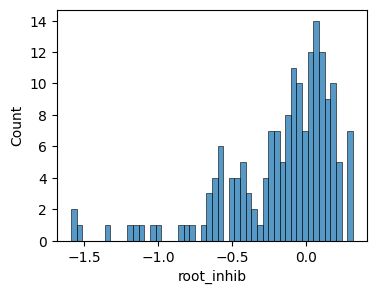

In [ ]:
plt.figure(figsize=(4,3))
sns.histplot(pheno['root_inhib'], bins=50)
plt.show

### The root growth inhibition is skewed. therefore it needs transformation.

In [ ]:
# log transfform the root_length inhibition.
pheno['root_inhib_log'] = np.log10(pheno['root_inhib'])

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/var/folders/rk/kh1g1yz15_b539v1q19bprcr0000gn/T/ipykernel_1311/478637227.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pheno['root_inhib_log'] = np.log10(pheno['root_inhib'])


<function matplotlib.pyplot.show(close=None, block=None)>

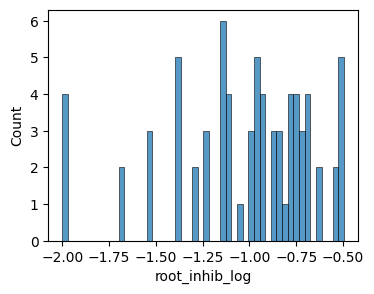

In [ ]:
plt.figure(figsize=(4,3))
sns.histplot(pheno['root_inhib_log'], bins=50)
plt.show

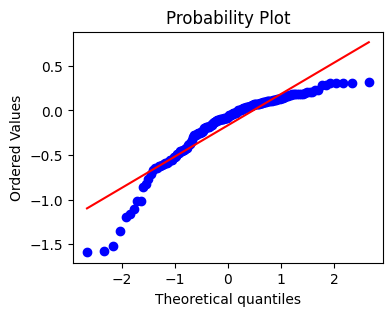

In [ ]:
plt.figure(figsize=(4,3))
stats.probplot(pheno['root_inhib'], dist="norm", plot=plt)
plt.show()

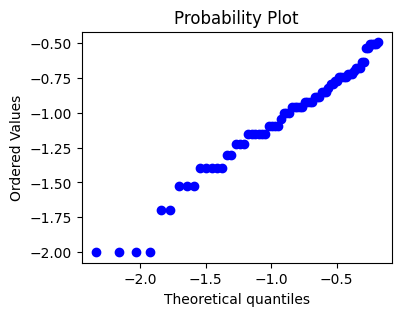

In [ ]:
plt.figure(figsize=(4,3))
stats.probplot(pheno['root_inhib_log'], dist="norm", plot=plt)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

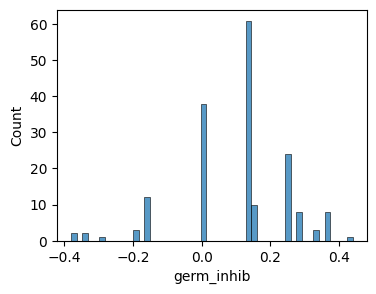

In [ ]:
plt.figure(figsize=(4,3))
sns.histplot(pheno['germ_inhib'], bins=50)
plt.show